# Task
Fetch stock data for a user-specified Taiwanese stock ticker for the past 10 years and save it to a CSV file.

## 安裝必要的套件

### Subtask:
安裝用於股票資料抓取的 `yfinance` 套件。


**Reasoning**:
The subtask requires installing the `yfinance` package, so I will use `pip` to install it.



In [1]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


## 匯入所需套件

### Subtask:
匯入 `yfinance` 和 `pandas` 套件，以便進行資料抓取與處理。


**Reasoning**:
The subtask requires importing `yfinance` and `pandas` packages. I will create a code block to import these packages, aliasing `pandas` as `pd`.



In [2]:
import yfinance as yf
import pandas as pd
print("yfinance and pandas packages imported successfully.")

yfinance and pandas packages imported successfully.


## 定義抓取股票資料的函數

### Subtask:
建立一個函數，輸入股票代碼，抓取近十年的每日收盤價、最高價、最低價等資訊。


**Reasoning**:
The subtask requires defining a function to fetch stock data for the past 10 years. I will create a Python function `fetch_stock_data` that takes a ticker as input, calculates the start and end dates, uses `yfinance` to download the historical data, and returns a pandas DataFrame.



In [3]:
from datetime import datetime, timedelta

def fetch_stock_data(ticker):
    """
    Fetches historical stock data for a given ticker for the past 10 years.

    Args:
        ticker (str): The stock ticker symbol (e.g., '2330.TW' for TSMC).

    Returns:
        pandas.DataFrame: Historical stock data including Open, High, Low, Close, Volume, etc.
                          Returns an empty DataFrame if data fetching fails.
    """
    end_date = datetime.now()
    start_date = end_date - timedelta(days=10*365) # Approximate 10 years

    try:
        stock = yf.Ticker(ticker)
        # Fetch daily data for the specified period
        data = stock.history(start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), interval='1d')
        if data.empty:
            print(f"No data found for {ticker} in the last 10 years.")
        else:
            print(f"Successfully fetched data for {ticker} from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}.")
        return data
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return pd.DataFrame() # Return an empty DataFrame on error

print("fetch_stock_data function defined.")

fetch_stock_data function defined.


## 讓使用者輸入股票代碼

### Subtask:
提示使用者輸入要查詢的台灣股票代碼。


**Reasoning**:
The subtask requires prompting the user for a Taiwanese stock ticker and reminding them about the '.TW' suffix. I will use the `input()` function to get the ticker from the user and store it in a variable.



In [4]:
# @title
ticker_symbol = "2330.TW" 
print(f"系統自動執行，抓取標的: {ticker_symbol}")

系統自動執行，抓取標的: 2330.TW


In [5]:
stock_data = fetch_stock_data(ticker_symbol)

if not stock_data.empty:
    filename = f"{ticker_symbol.replace('.TW', '')}_stock_data.csv"
    stock_data.to_csv(filename, index=True) # index=True to save the Date as a column
    print(f"股票資料已成功儲存為 {filename}")
else:
    print(f"無法為 {ticker_symbol} 抓取到股票資料，因此沒有檔案儲存。")

Successfully fetched data for 2330.TW from 2016-03-26 to 2026-03-24.
股票資料已成功儲存為 2330_stock_data.csv


In [6]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Load the data into a DataFrame and set 'Date' as index
file_path = filename
stock_df = pd.read_csv(file_path, index_col='Date', parse_dates=True)
print(f"Data loaded from {file_path}. First 5 rows:\n{stock_df.head()}\n")

# 2. Extract 'Close' prices
close_prices = stock_df['Close'].values.reshape(-1, 1)
print(f"'Close' prices extracted. Shape: {close_prices.shape}\n")

# 3. Instantiate MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# 4. Fit and transform 'Close' prices
scaled_close_prices = scaler.fit_transform(close_prices)
print("Close prices standardized using MinMaxScaler.")
print(f"Scaled Close prices first 5 values: {scaled_close_prices[:5].flatten()}\n")

# 5. Define look_back variable
look_back = 100
print(f"look_back period defined as: {look_back}")

Data loaded from 2330_stock_data.csv. First 5 rows:
                                 Open        High         Low       Close  \
Date                                                                        
2016-03-28 00:00:00+08:00  119.546993  120.303619  118.790366  120.303619   
2016-03-29 00:00:00+08:00  119.925306  120.681933  119.546993  120.303619   
2016-03-30 00:00:00+08:00  119.925303  122.573496  119.925303  122.195183   
2016-03-31 00:00:00+08:00  122.573532  123.330159  120.303652  122.573532   
2016-04-01 00:00:00+08:00  121.816890  121.816890  119.168697  119.925323   

                             Volume  Dividends  Stock Splits  
Date                                                          
2016-03-28 00:00:00+08:00  15268000        0.0           0.0  
2016-03-29 00:00:00+08:00  18977000        0.0           0.0  
2016-03-30 00:00:00+08:00  43616000        0.0           0.0  
2016-03-31 00:00:00+08:00  49433000        0.0           0.0  
2016-04-01 00:00:00+08:00  315

In [7]:
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

# 6. Create the X and y datasets
X, y = create_dataset(scaled_close_prices, look_back)
print(f"X dataset shape before reshaping: {X.shape}")
print(f"y dataset shape: {y.shape}")

# 7. Reshape X to be [samples, time_steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
print(f"X dataset shape after reshaping: {X.shape}")

X dataset shape before reshaping: (2327, 100)
y dataset shape: (2327,)
X dataset shape after reshaping: (2327, 100, 1)


## Split Data into Training and Testing Sets

### Subtask:
Divide the preprocessed `X` (features) and `y` (labels) datasets into distinct training and testing sets.


**Reasoning**:
The subtask requires splitting the `X` and `y` datasets into training and testing sets while preserving temporal order. I will use `sklearn.model_selection.train_test_split` with `test_size=0.2` and `shuffle=False`.



In [8]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (95% train, 5% test)
# shuffle=False is crucial to maintain the temporal order of the time series data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, shuffle=False)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2210, 100, 1)
X_test shape: (117, 100, 1)
y_train shape: (2210,)
y_test shape: (117,)


## Define LSTM Model with Attention Mechanism

### Subtask:
Design a new Keras/TensorFlow Sequential model that integrates an Attention layer with the existing LSTM layers. This will allow the model to dynamically weight different parts of the input sequence, potentially improving prediction accuracy.


**Reasoning**:
The subtask requires designing a new Keras/TensorFlow Sequential model with an Attention layer. I will start by defining the custom Attention layer class as specified in the instructions, and then build the sequential model incorporating this custom layer along with LSTM and Dense layers.



In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Layer
import tensorflow.keras.backend as K
import tensorflow as tf

# 1. Define a custom Attention layer class
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], input_shape[-1]),
                               initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[-1],),
                               initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        # x is the input from the previous layer (LSTM with return_sequences=True)
        # Calculate attention scores
        # ui = tanh(xW + b)
        ui = K.tanh(K.dot(x, self.W) + self.b)

        # Context vector (usually a learnable parameter or a fixed vector of ones)
        # For simplicity, we can use a vector of ones here. A more complex attention
        # might involve another dense layer to calculate the context vector u_w.
        uw = K.ones_like(ui[:, :, 0]) # Create a vector of ones with the same time steps
        # Reshape for broadcasting
        uw = K.expand_dims(uw)

        # Alpha = softmax(ui * uw)
        alpha = K.softmax(K.sum(ui * uw, axis=2))
        alpha = K.expand_dims(alpha)

        # Context vector z = sum(alpha * x)
        context_vector = K.sum(x * alpha, axis=1)
        return context_vector

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])
# 2. Initialize a Sequential model
model_with_attention = Sequential()

# 3. Add an Input layer
model_with_attention.add(Input(shape=(look_back, 1)))

# 4. Add an LSTM layer with return_sequences=True for the Attention layer
model_with_attention.add(LSTM(units=128, return_sequences=True))
model_with_attention.add(LSTM(units=64, return_sequences=True))

# 5. Add the custom Attention layer
model_with_attention.add(Attention())

# 6. Add a Dense output layer
model_with_attention.add(Dense(units=1))

# Compile the model (optional, but good practice to show it's a complete model)
model_with_attention.compile(optimizer='adam', loss='mean_squared_error')

# 7. Print the model summary
print("LSTM model with Attention layer defined and compiled.")
model_with_attention.summary()

LSTM model with Attention layer defined and compiled.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,193 (469.50 KB)

 Trainable params: 120,193 (469.50 KB)

 Non-trainable params: 0 (0.00 B)

## Compile Attention-LSTM Model

### Subtask:
Compile the newly defined Attention-LSTM model with an appropriate optimizer (e.g., 'adam') and a loss function suitable for regression tasks (e.g., 'mean_squared_error').


**Reasoning**:
The subtask requires compiling the already defined Attention-LSTM model. I will use the `compile` method with 'adam' optimizer and 'mean_squared_error' loss, and then print a confirmation message.



In [10]:
print("Compiling the Attention-LSTM model...")
model_with_attention.compile(optimizer='adam', loss='mean_squared_error')
print("Attention-LSTM model compiled successfully.")

Compiling the Attention-LSTM model...
Attention-LSTM model compiled successfully.


## Train Attention-LSTM Model

### Subtask:
Train the Attention-LSTM model using the prepared training data (`X_train`, `y_train`). Monitor the loss during training to ensure convergence.


**Reasoning**:
I will train the `model_with_attention` using the `X_train` and `y_train` datasets, as well as the specified epochs and batch size, to fit the model to the training data.



In [11]:
print("Starting Attention-LSTM model training...")
# 1. Train the Attention-LSTM model
# Using X_train as input data and y_train as labels
# Set epochs and batch_size as per instructions
history_attention = model_with_attention.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

print("Attention-LSTM model training completed.")

Starting Attention-LSTM model training...
Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 0.0036
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 9.0055e-04
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.0010    
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 7.8869e-04
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 7.8184e-04
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 7.1641e-04
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 6.7375e-04
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 4.6960e-04
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 4.1568e-04
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 1.8386e-04
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 2.0986e-04
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 2.3758e-04
Epoch 13/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 1.2195e-04
Epoch 14/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/s

## Make Predictions with Attention-LSTM Model

### Subtask:
Use the trained Attention-LSTM model to make predictions on both the training data (`X_train`) and the unseen test data (`X_test`).


**Reasoning**:
The subtask requires making predictions on both training and testing data using the trained Attention-LSTM model. I will use the `model_with_attention.predict()` method for `X_train` and `X_test`, and then print their shapes to confirm the output dimensions.



In [12]:
print("Generating predictions using Attention-LSTM model...")

# 1. Generate predictions for the training dataset
train_predict_attention = model_with_attention.predict(X_train)

# 2. Generate predictions for the testing dataset
test_predict_attention = model_with_attention.predict(X_test)

# 3. Print the shapes of the prediction arrays
print(f"Shape of train_predict_attention: {train_predict_attention.shape}")
print(f"Shape of test_predict_attention: {test_predict_attention.shape}")

print("Predictions generated successfully.")

Generating predictions using Attention-LSTM model...
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Shape of train_predict_attention: (2210, 1)
Shape of test_predict_attention: (117, 1)
Predictions generated successfully.


## Inverse Transform Predictions and Actual Values

### Subtask:
Convert both the predicted values and the actual values (for both training and testing sets) back to their original stock price scale using the `scaler` object. This is necessary for meaningful interpretation and evaluation.


**Reasoning**:
The subtask requires inverse transforming the predicted and actual values for both training and testing sets to their original scale using the `scaler` object. I will apply `scaler.inverse_transform()` to each array, ensuring `y_train` and `y_test` are reshaped correctly before transformation, and then print the shapes.



In [13]:
print("Inverse transforming predictions and actual values...")

# 1. Inverse transform train_predict_attention
train_predict_attention = scaler.inverse_transform(train_predict_attention)

# 2. Inverse transform test_predict_attention
test_predict_attention = scaler.inverse_transform(test_predict_attention)

# 3. Inverse transform y_train (reshape before transforming)
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))

# 4. Inverse transform y_test (reshape before transforming)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# 5. Print the shapes of the inverse-transformed arrays
print(f"Shape of inverse transformed train_predict_attention: {train_predict_attention.shape}")
print(f"Shape of inverse transformed test_predict_attention: {test_predict_attention.shape}")
print(f"Shape of inverse transformed y_train_inverse: {y_train_inverse.shape}")
print(f"Shape of inverse transformed y_test_inverse: {y_test_inverse.shape}")

print("Inverse transformation completed.")

Inverse transforming predictions and actual values...
Shape of inverse transformed train_predict_attention: (2210, 1)
Shape of inverse transformed test_predict_attention: (117, 1)
Shape of inverse transformed y_train_inverse: (2210, 1)
Shape of inverse transformed y_test_inverse: (117, 1)
Inverse transformation completed.


## Visualize Attention-LSTM Predictions

### Subtask:
Create a visualization (e.g., a line plot) comparing the inverse-transformed predicted stock prices against the actual stock prices for both the training and testing sets. This will help assess the model's performance and generalization. Ensure to include legends for clarity.


**Reasoning**:
The subtask requires visualizing the Attention-LSTM model's predictions against actual values for both training and testing sets to assess performance. I will generate a code block to create a line plot using `matplotlib.pyplot`, plotting the inverse-transformed actual and predicted values for both sets with proper labels, title, and legends.



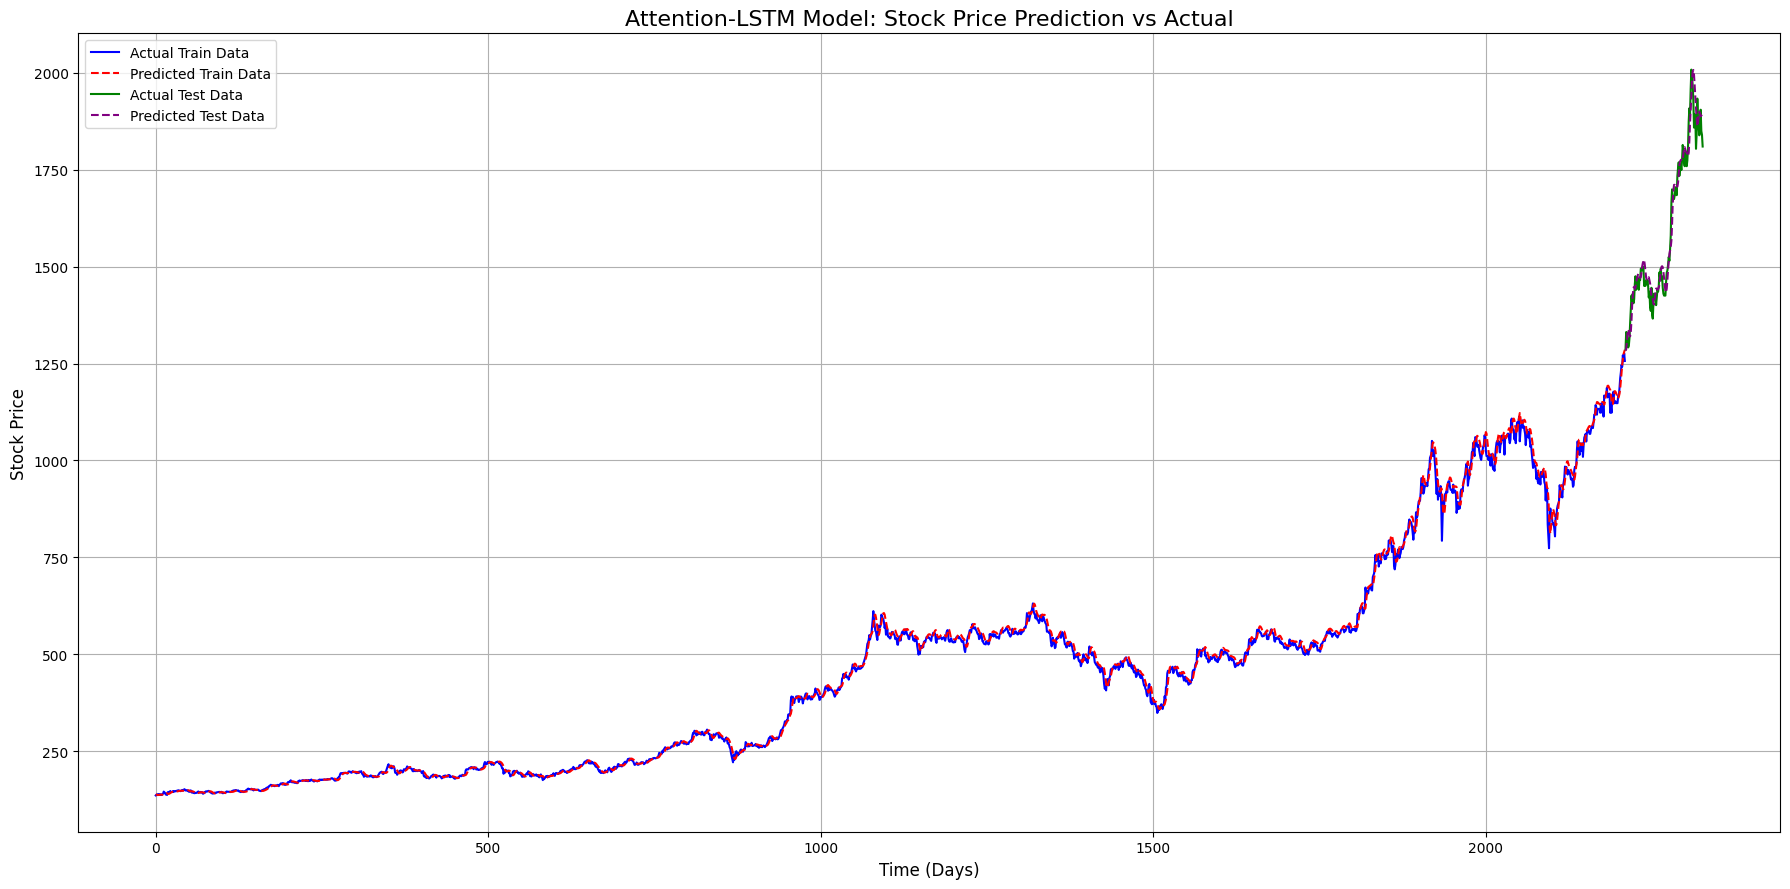

Visualization of Attention-LSTM predictions complete.


In [14]:
import matplotlib.pyplot as plt

# Create a figure and an axes object for the plot
fig, ax = plt.subplots(figsize=(18, 9))

# Plot Actual Train Data
ax.plot(y_train_inverse, label='Actual Train Data', color='blue', linewidth=1.5)

# Plot Predicted Train Data
ax.plot(train_predict_attention, label='Predicted Train Data', color='red', linestyle='--', linewidth=1.5)

# Create an index for the test data that starts after the training data
test_data_indices = range(len(y_train_inverse), len(y_train_inverse) + len(y_test_inverse))

# Plot Actual Test Data
ax.plot(test_data_indices, y_test_inverse, label='Actual Test Data', color='green', linewidth=1.5)

# Plot Predicted Test Data
ax.plot(test_data_indices, test_predict_attention, label='Predicted Test Data', color='purple', linestyle='--', linewidth=1.5)

# Add title and labels
ax.set_title('Attention-LSTM Model: Stock Price Prediction vs Actual', fontsize=16)
ax.set_xlabel('Time (Days)', fontsize=12)
ax.set_ylabel('Stock Price', fontsize=12)

# Add legend
ax.legend(loc='upper left', fontsize=10)

# Add grid
ax.grid(True)

# Display the plot
plt.tight_layout()
plt.show()
print("Visualization of Attention-LSTM predictions complete.")

## Evaluate Attention-LSTM Model Performance

### Subtask:
Calculate and report evaluation metrics, such as Root Mean Squared Error (RMSE), for both the training and testing predictions to quantitatively assess the performance of the Attention-LSTM model. This will provide a clear measure of accuracy.


The Root Mean Squared Error (RMSE) is a commonly used metric to measure the difference between values predicted by a model and the values observed. In the context of stock price prediction, RMSE quantifies the average magnitude of the errors made by the model in predicting stock prices. A lower RMSE value indicates a better fit of the model to the data. It is particularly useful because it gives a relatively high weight to large errors, meaning it is sensitive to outliers. The RMSE values for both the training and testing sets will indicate how well the Attention-LSTM model learned from the historical data and how well it generalizes to unseen data, respectively.

**Reasoning**:
Now that the explanation for RMSE has been provided, I will print the already calculated `train_rmse` and `test_rmse` values to report the evaluation metrics as required by the subtask.



In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    # Avoid division by zero by replacing 0 actual values with a small epsilon or handling them
    # Here we'll just ignore cases where y_true is 0, which might not be ideal for all scenarios
    # For stock prices, 0 is unlikely, but good to be aware.
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Filter out zero values in y_true to prevent division by zero
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan # Or raise an error if no non-zero actual values

    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# Calculate RMSE for training data
train_rmse = np.sqrt(mean_squared_error(y_train_inverse, train_predict_attention))

# Calculate MAE for training data
train_mae = mean_absolute_error(y_train_inverse, train_predict_attention)

# Calculate MAPE for training data
train_mape = mean_absolute_percentage_error(y_train_inverse, train_predict_attention)

# Calculate RMSE for testing data
test_rmse = np.sqrt(mean_squared_error(y_test_inverse, test_predict_attention))

# Calculate MAE for testing data
test_mae = mean_absolute_error(y_test_inverse, test_predict_attention)

# Calculate MAPE for testing data
test_mape = mean_absolute_percentage_error(y_test_inverse, test_predict_attention)

print("Attention-LSTM Model Performance Metrics:")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Train MAE: {train_mae:.4f}")
print(f"Train MAPE: {train_mape:.2f}%")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test MAPE: {test_mape:.2f}%")

Attention-LSTM Model Performance Metrics:
Train RMSE: 13.9322
Train MAE: 8.9508
Train MAPE: 1.88%
Test RMSE: 40.0369
Test MAE: 31.0614
Test MAPE: 1.93%


# Phase 1: Model Tuning & Optimization

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K
from sklearn.metrics import mean_squared_error

print("--- 準備完全體特徵 (Returns, RSI, MA5_Bias, MA20_Bias) ---")

# 1. 建立特徵工程 DataFrame
df_features = pd.DataFrame({'Close': stock_df['Close'].values})

# A. 計算單日報酬率 (Return)
df_features['Return'] = df_features['Close'].pct_change()

# B. 計算 RSI-14
delta = df_features['Close'].diff()
gain = (delta.where(delta > 0, 0)).ewm(alpha=1/14, adjust=False).mean()
loss = (-delta.where(delta < 0, 0)).ewm(alpha=1/14, adjust=False).mean()
rs = gain / loss
df_features['RSI'] = 100 - (100 / (1 + rs))

# C. 計算 MA5 與 MA20 的乖離率 (Bias)
ma5 = df_features['Close'].rolling(window=5).mean()
ma20 = df_features['Close'].rolling(window=20).mean()
df_features['MA5_Bias'] = (df_features['Close'] - ma5) / ma5
df_features['MA20_Bias'] = (df_features['Close'] - ma20) / ma20

# 移除因為計算 MA20 產生的前 20 天 NaN
df_features = df_features.dropna().reset_index(drop=True)

# 2. 進行多變量正規化 (確保所有輸入都在 0~1 之間)
features_to_scale = df_features[['Return', 'RSI', 'MA5_Bias', 'MA20_Bias']]
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler_features.fit_transform(features_to_scale)

# 準備一個專屬用來還原 Return (第0個欄位) 的 Scaler
scaler_return = MinMaxScaler(feature_range=(0, 1))
scaler_return.fit(df_features[['Return']])

# 3. 重新建立資料集 (目標 Y 依然是「明天的 Return」)
look_back = 30
X, Y_return, prev_closes, actual_closes = [], [], [], []

for i in range(len(scaled_data) - look_back):
    X.append(scaled_data[i:(i + look_back), :]) # 過去 30 天的 4 個特徵
    Y_return.append(scaled_data[i + look_back, 0]) # 目標：預測第 0 個特徵 (Return)
    
    # 紀錄股價以便最後還原算 MAPE
    prev_closes.append(df_features['Close'].iloc[i + look_back - 1])
    actual_closes.append(df_features['Close'].iloc[i + look_back])

X = np.array(X)
Y_return = np.array(Y_return)
prev_closes = np.array(prev_closes)
actual_closes = np.array(actual_closes)

# 4. 切分 Train / Test (95% / 5%)
split_idx = int(len(X) * 0.95)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = Y_return[:split_idx], Y_return[split_idx:]
prev_closes_test = prev_closes[split_idx:]
actual_closes_test = actual_closes[split_idx:]

# 5. 建立模型 (輸入層改為 4 個特徵)
K.clear_session()
model = Sequential()
model.add(Input(shape=(look_back, 4))) # ⚠️ 注意：特徵數變成 4 了
model.add(LSTM(units=64, return_sequences=True))
model.add(LSTM(units=32, return_sequences=True))
model.add(Attention())
model.add(Dense(units=1))

model.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error')

# 6. 設定雙重防護 Callbacks
# A. 早停機制
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

# B. 學習率衰減 (如果 3 個 epoch 沒進步，學習率就砍半)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

print("\n開始訓練「完全體」模型 (開啟 Early Stopping & LR Scheduler)...")
# ⚠️ 將兩個 callback 都放入列表中
model.fit(X_train, y_train, validation_data=(X_test, y_test), 
          epochs=150, batch_size=32, verbose=1, callbacks=[early_stop, lr_scheduler])

# 7. 預測與數值還原
print("\n正在將預測的「報酬率」還原為「真實股價」以計算誤差...")
test_pred_scaled = model.predict(X_test, verbose=0)
test_pred_return = scaler_return.inverse_transform(test_pred_scaled).flatten()

# 預測股價 = 昨天的真實股價 * (1 + 預測報酬率)
predicted_prices = prev_closes_test * (1 + test_pred_return)

# 8. 計算最終表現
test_mape = np.mean(np.abs((actual_closes_test - predicted_prices) / actual_closes_test)) * 100
test_rmse = np.sqrt(mean_squared_error(actual_closes_test, predicted_prices))

print("\n=======================================================")
print("  完全體最佳模型表現 (Return+RSI+Bias + ES+LRScheduler)  ")
print("=======================================================")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAPE: {test_mape:.2f}%")
print("=======================================================")

--- 準備完全體特徵 (Returns, RSI, MA5_Bias, MA20_Bias) ---


開始訓練「完全體」模型 (開啟 Early Stopping & LR Scheduler)...
Epoch 1/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0250 - val_loss: 0.0101 - learning_rate: 5.0000e-04
Epoch 2/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0079 - val_loss: 0.0092 - learning_rate: 5.0000e-04
Epoch 3/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0077 - val_loss: 0.0090 - learning_rate: 5.0000e-04
Epoch 4/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0076 - val_loss: 0.0088 - learning_rate: 5.0000e-04
Epoch 5/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0075 - val_loss: 0.0088 - learning_rate: 5.0000e-04
Epoch 6/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0075 - val_loss: 0.0090 - learning_rate: 5.0000e-04
Epoch 7/150
67/71 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0075
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0077 - val_loss: 0.0089 - l

# Phase 2: Rolling Forecast Simulation


  Phase 2: 滾動預測模擬 (資料集最後 10 天)
📊 資料集總共 2378 筆，取最後 10 天 (Index 2368 ~ 2377)
📅 對應日期範圍: 資料集中離現在最近的 10 個交易日


--- 🚀 模擬第 1 天 (Index: 2368) ---
訓練集: 2368 筆 (100% 歷史資料)
昨日收盤: 1804.11
預測今日: 1808.95 | 真實今日: 1843.98 | 誤差: 35.03
✅ Day 1 完成！

--- 🚀 模擬第 2 天 (Index: 2369) ---
訓練集: 2369 筆 (100% 歷史資料)
昨日收盤: 1843.98
預測今日: 1845.61 | 真實今日: 1933.69 | 誤差: 88.08
✅ Day 2 完成！

--- 🚀 模擬第 3 天 (Index: 2370) ---
訓練集: 2370 筆 (100% 歷史資料)
昨日收盤: 1933.69
預測今日: 1936.11 | 真實今日: 1878.87 | 誤差: 57.24
✅ Day 3 完成！

--- 🚀 模擬第 4 天 (Index: 2371) ---
訓練集: 2371 筆 (100% 歷史資料)
昨日收盤: 1878.87
預測今日: 1880.74 | 真實今日: 1858.93 | 誤差: 21.81
✅ Day 4 完成！

--- 🚀 模擬第 5 天 (Index: 2372) ---
訓練集: 2372 筆 (100% 歷史資料)
昨日收盤: 1858.93
預測今日: 1859.77 | 真實今日: 1839.00 | 誤差: 20.77
✅ Day 5 完成！

--- 🚀 模擬第 6 天 (Index: 2373) ---
訓練集: 2373 筆 (100% 歷史資料)
昨日收盤: 1839.00
預測今日: 1841.94 | 真實今日: 1870.00 | 誤差: 28.06
✅ Day 6 完成！

--- 🚀 模擬第 7 天 (Index: 2374) ---
訓練集: 2374 筆 (100% 歷史資料)
昨日收盤: 1870.00
預測今日: 1868.12 | 真實今日: 1905.00 | 誤差: 36.88
✅ Day 7 完成！

--- 🚀 模擬第 8 天 (Ind

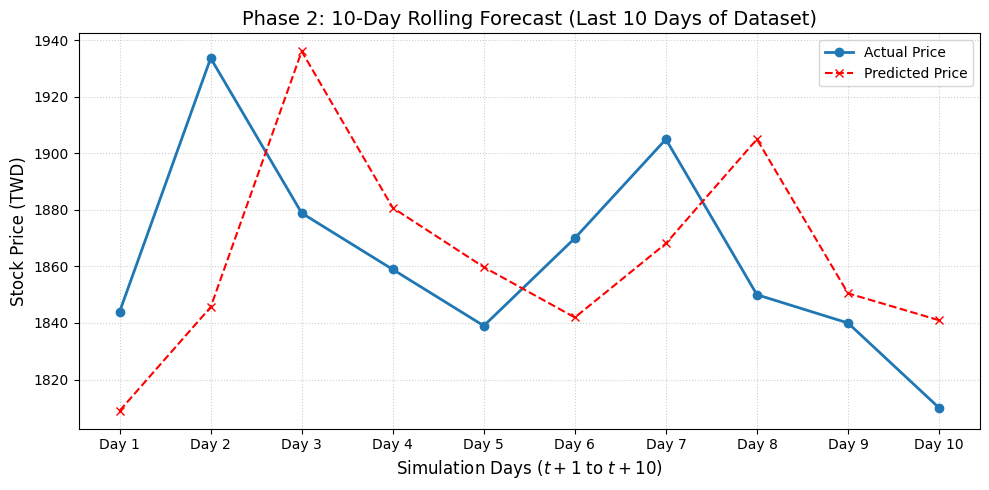

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K

print("\n=======================================================")
print("  Phase 2: 滾動預測模擬 (資料集最後 10 天)")
print("=======================================================")

rolling_days = 10
start_idx = len(X) - rolling_days

rolling_predictions = []
rolling_actuals = []
dates_labels = []

print(f"📊 資料集總共 {len(X)} 筆，取最後 {rolling_days} 天 (Index {start_idx} ~ {len(X)-1})")
print(f"📅 對應日期範圍: 資料集中離現在最近的 {rolling_days} 個交易日\n")

for i in range(rolling_days):
    idx = start_idx + i
    day_num = i + 1
    print(f"\n--- 🚀 模擬第 {day_num} 天 (Index: {idx}) ---")
    
    # 1. 取 idx 之前的所有資料作為訓練集
    X_train_rolling = X[:idx]
    Y_train_rolling = Y_return[:idx]
    
    print(f"訓練集: {len(X_train_rolling)} 筆 (100% 歷史資料)")
    
    # 2. 模型架構與 Phase 1 完全一致
    K.clear_session()
    model_rolling = Sequential()
    model_rolling.add(Input(shape=(look_back, 4)))
    model_rolling.add(LSTM(units=64, return_sequences=True))
    model_rolling.add(LSTM(units=32, return_sequences=True))
    model_rolling.add(Attention())
    model_rolling.add(Dense(units=1))
    model_rolling.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error')
    
    # Callbacks 與 Phase 1 完全一致
    early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True, verbose=0)
    lr_scheduler = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, min_lr=1e-5, verbose=0)
    
    model_rolling.fit(X_train_rolling, Y_train_rolling,
                      epochs=150, batch_size=32, verbose=0,
                      callbacks=[early_stop, lr_scheduler])
    
    # 3. 預測
    current_X = X[idx:idx+1]
    pred_scaled = model_rolling.predict(current_X, verbose=0)
    pred_return = scaler_return.inverse_transform(pred_scaled)[0][0]
    
    # 4. 還原成預測股價
    yesterday_close = prev_closes[idx]
    predicted_price = yesterday_close * (1 + pred_return)
    rolling_predictions.append(predicted_price)
    
    # 5. 真實股價
    actual_price = actual_closes[idx]
    rolling_actuals.append(actual_price)
    dates_labels.append(f"Day {day_num}")
    
    print(f"昨日收盤: {yesterday_close:.2f}")
    print(f"預測今日: {predicted_price:.2f} | 真實今日: {actual_price:.2f} | 誤差: {abs(predicted_price - actual_price):.2f}")
    print(f"✅ Day {day_num} 完成！")

# 6. 計算誤差指標
rolling_mape = np.mean(np.abs((np.array(rolling_actuals) - np.array(rolling_predictions)) / np.array(rolling_actuals))) * 100
rolling_rmse = np.sqrt(mean_squared_error(rolling_actuals, rolling_predictions))

print("\n=======================================================")
print(f" 階段二 (最後 {rolling_days} 日) 表現")
print(f"  -> RMSE: {rolling_rmse:.4f}")
print(f"  -> MAPE: {rolling_mape:.2f}%")
print("=======================================================")

# 7. 畫圖
plt.figure(figsize=(10, 5))
plt.plot(dates_labels, rolling_actuals, marker='o', label='Actual Price', linewidth=2)
plt.plot(dates_labels, rolling_predictions, marker='x', label='Predicted Price', linestyle='--', color='red')
plt.title("Phase 2: 10-Day Rolling Forecast (Last 10 Days of Dataset)", fontsize=14)
plt.xlabel("Simulation Days ($t+1$ to $t+10$)", fontsize=12)
plt.ylabel("Stock Price (TWD)", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


# Phase 3: The Live Trading Competition

### 使用方式：
1. **第一天**：依序執行 Cell A → Cell B → Cell C
2. **第二天起**：只需執行 Cell B → Cell C（Cell A 只跑一次）
3. **最後一天 (Day 10)**：執行 Cell B → Cell C 後，再執行 Cell D 清算
4. **隨時查看**：執行 Cell E 查看完整交易紀錄

### Cell B 每次執行會：
- 重新抓取最新股價（包含你手動等到的今日收盤）
- 用 **100% 歷史資料**重新訓練模型
- 回報 100% 訓練集的 **RMSE / MAPE**
- 預測明天的收盤價與預期報酬率

### Cell C 每次執行會：
- 根據你填入的 action / quantity 執行交易
- 自動記錄到 JSON 檔（關掉 notebook 也不會遺失）

## Cell A: 初始化（只需執行一次）

In [18]:
import json
import os
from datetime import datetime, timedelta
# ========== 超參數設定 (沿用 Phase 1) ==========
look_back = 30
TICKER = '2330.TW'

# ========== 初始資金 ==========
initial_capital = 10000000.0  # 1000 萬台幣

# ========== 預測信心倍率 ==========
CONFIDENCE_MULTIPLIER = 1.0

# ========== MA20 偏離度策略閾值（10 級倉位）==========
# bias = (預測明日股價 - 目前MA20) / 目前MA20
# 預測價高於 MA20 → 賣出；預測價低於 MA20 → 買入
#
#  偏離 MA20    |  動作
# -------------+------------------
#  > +10%       |  賣出 100%
#  > +9%        |  賣出 90%
#  > +8%        |  賣出 80%
#  > +7%        |  賣出 70%
#  > +6%        |  賣出 60%
#  > +5%        |  賣出 50%
#  > +4%        |  賣出 40%
#  > +3%        |  賣出 30%
#  > +2%        |  賣出 20%
#  > +1%        |  賣出 10%
#  -1% ~ +1%   |  Hold
#  < -1%        |  買進 10%
#  < -2%        |  買進 20%
#  < -3%        |  買進 30%
#  < -4%        |  買進 40%
#  < -5%        |  買進 50%
#  < -6%        |  買進 60%
#  < -7%        |  買進 70%
#  < -8%        |  買進 80%
#  < -9%        |  買進 90%
#  < -10%       |  買進 100%

# 賣出閾值（由高到低排列），等距 ±1%~±10%，對應賣出 100%~10%
sell_thresholds = [
    (0.10, 1.0),   # 偏離 > +10% -> 賣出 100%
    (0.09, 0.9),   # 偏離 > +9%  -> 賣出 90%
    (0.08, 0.8),   # 偏離 > +8%  -> 賣出 80%
    (0.07, 0.7),   # 偏離 > +7%  -> 賣出 70%
    (0.06, 0.6),   # 偏離 > +6%  -> 賣出 60%
    (0.05, 0.5),   # 偏離 > +5%  -> 賣出 50%
    (0.04, 0.4),   # 偏離 > +4%  -> 賣出 40%
    (0.03, 0.3),   # 偏離 > +3%  -> 賣出 30%
    (0.02, 0.2),   # 偏離 > +2%  -> 賣出 20%
    (0.01, 0.1),   # 偏離 > +1%  -> 賣出 10%
]

# 買進閾值（由低到高排列），等距 ±1%~±10%，對應買進 100%~10%
buy_thresholds = [
    (-0.10, 1.0),  # 偏離 < -10% -> 買進 100%
    (-0.09, 0.9),  # 偏離 < -9%  -> 買進 90%
    (-0.08, 0.8),  # 偏離 < -8%  -> 買進 80%
    (-0.07, 0.7),  # 偏離 < -7%  -> 買進 70%
    (-0.06, 0.6),  # 偏離 < -6%  -> 買進 60%
    (-0.05, 0.5),  # 偏離 < -5%  -> 買進 50%
    (-0.04, 0.4),  # 偏離 < -4%  -> 買進 40%
    (-0.03, 0.3),  # 偏離 < -3%  -> 買進 30%
    (-0.02, 0.2),  # 偏離 < -2%  -> 買進 20%
    (-0.01, 0.1),  # 偏離 < -1%  -> 買進 10%
]

# ========== 交易紀錄檔 ==========
TRADE_LOG_FILE = 'phase3_trade_log.json'

if os.path.exists(TRADE_LOG_FILE):
    with open(TRADE_LOG_FILE, 'r') as f:
        trade_state = json.load(f)
    print(f"✅ 已載入既有交易紀錄，目前已完成 {len(trade_state['trades'])} 天")
else:
    trade_state = {
        'initial_capital': initial_capital,
        'cash': initial_capital,
        'shares': 0,
        'trades': [],
        'predictions': [],
        'actuals': []
    }
    with open(TRADE_LOG_FILE, 'w') as f:
        json.dump(trade_state, f, indent=2, ensure_ascii=False)
    print("🆕 已建立新的交易紀錄檔案")

print("\n=======================================================")
print("  Phase 3: 終極實盤動態交易系統 (MA20 偏離度策略) ")
print("=======================================================")
print(f"💰 目前現金: {trade_state['cash']:,.0f} TWD")
print(f"📊 目前持股: {trade_state['shares']:,} 股")
print(f"📝 已完成交易天數: {len(trade_state['trades'])} 天")
print(f"\n📌 策略邏輯：依預測價偏離 MA20 的程度來決定買賣")
print(f"              預測價 > MA20 → 賣出 / 預測價 < MA20 → 買入")
print(f"              10 級等距倉位，偏離 ±1%~±10% 對應 10%~100%")
print(f"🔧 預測信心倍率: {CONFIDENCE_MULTIPLIER}x")
print("\n🎯 初始化完成！請繼續執行 Cell B 來訓練模型並預測。")


✅ 已載入既有交易紀錄，目前已完成 2 天

  Phase 3: 終極實盤動態交易系統 (MA20 偏離度策略) 
💰 目前現金: 4,103,020 TWD
📊 目前持股: 3,258 股
📝 已完成交易天數: 2 天

📌 策略邏輯：依預測價偏離 MA20 的程度來決定買賣
              預測價 > MA20 → 賣出 / 預測價 < MA20 → 買入
              10 級等距倉位，偏離 ±1%~±10% 對應 10%~100%
🔧 預測信心倍率: 1.0x

🎯 初始化完成！請繼續執行 Cell B 來訓練模型並預測。


## Cell B: 每日執行 — 抓資料 → 100% 重訓模型 → 預測明天

**每天收盤後執行此 Cell**

In [37]:
day_num = len(trade_state['trades']) + 1

print("\n=======================================================")
print(f"  🚀 執行 Day {day_num} 實盤模擬")
print("=======================================================")

# ============================================================
#  👇👇👇 每天修改這個變數：填入今天的收盤價 👇👇👇
#  (因為 yfinance 在當天晚上 12 點後才會更新今日資料，
#   所以 9 PM 前只能抓到昨天的資料，需要手動補上今天的收盤價)
#  如果 yfinance 已經有今天的資料 (例如隔天才跑)，設成 None 即可跳過
# ============================================================
today_manual_close = 1810   # ← 改成今天的收盤價，或 None 跳過
today_manual_date = '2026-04-02'  # ← 改成今天的日期
# ============================================================

# --- 1. 抓取最新股價資料 ---
print("\n📡 Step 1: 抓取最新股價資料...")
end_date = datetime.now()
start_date = end_date - timedelta(days=365*10)
stock_df = yf.download(TICKER, start=start_date.strftime('%Y-%m-%d'),
                       end=end_date.strftime('%Y-%m-%d'), auto_adjust=True)

if isinstance(stock_df.columns, pd.MultiIndex):
    stock_df.columns = stock_df.columns.get_level_values(0)

print(f"資料期間: {stock_df.index[0].strftime('%Y-%m-%d')} ~ {stock_df.index[-1].strftime('%Y-%m-%d')}")
print(f"總共 {len(stock_df)} 個交易日")

# --- 1.5 手動補上今日收盤價 (如果 yfinance 還沒更新) ---
if today_manual_close is not None:
    last_date_in_data = stock_df.index[-1].strftime('%Y-%m-%d')
    if last_date_in_data < today_manual_date:
        new_row = stock_df.iloc[-1:].copy()
        new_row.index = [pd.Timestamp(today_manual_date)]
        new_row['Close'] = today_manual_close
        new_row['Open'] = today_manual_close
        new_row['High'] = today_manual_close
        new_row['Low'] = today_manual_close
        stock_df = pd.concat([stock_df, new_row])
        print(f"✅ 已手動補上 {today_manual_date} 收盤價: {today_manual_close}")
        print(f"   資料更新至: {stock_df.index[-1].strftime('%Y-%m-%d')}，共 {len(stock_df)} 個交易日")
    else:
        print(f"ℹ️ yfinance 已包含 {today_manual_date} 的資料，跳過手動補入")
else:
    print("ℹ️ today_manual_close = None，使用 yfinance 原始資料")

# --- 2. 特徵工程 (與 Phase 1 完全一致，無去均值) ---
print("\n🔧 Step 2: 特徵工程 (Return, RSI, MA5_Bias, MA20_Bias)...")

df_features = pd.DataFrame({'Close': stock_df['Close'].values})
df_features['Return'] = df_features['Close'].pct_change()

delta = df_features['Close'].diff()
gain = (delta.where(delta > 0, 0)).ewm(alpha=1/14, adjust=False).mean()
loss = (-delta.where(delta < 0, 0)).ewm(alpha=1/14, adjust=False).mean()
rs = gain / loss
df_features['RSI'] = 100 - (100 / (1 + rs))

ma5 = df_features['Close'].rolling(window=5).mean()
ma20 = df_features['Close'].rolling(window=20).mean()
df_features['MA5_Bias'] = (df_features['Close'] - ma5) / ma5
df_features['MA20_Bias'] = (df_features['Close'] - ma20) / ma20

df_features['Date'] = stock_df.index.values[:len(df_features)]
df_features = df_features.dropna().reset_index(drop=True)

# --- 3. 正規化 & 建立 100% 資料集 (與 Phase 1 一致) ---
print("📐 Step 3: 正規化 & 建立資料集...")

features_to_scale = df_features[['Return', 'RSI', 'MA5_Bias', 'MA20_Bias']]
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler_features.fit_transform(features_to_scale)

scaler_return = MinMaxScaler(feature_range=(0, 1))
scaler_return.fit(df_features[['Return']])

X, Y_return, prev_closes, actual_closes = [], [], [], []
for i in range(len(scaled_data) - look_back):
    X.append(scaled_data[i:(i + look_back), :])
    Y_return.append(scaled_data[i + look_back, 0])
    prev_closes.append(df_features['Close'].iloc[i + look_back - 1])
    actual_closes.append(df_features['Close'].iloc[i + look_back])

X = np.array(X)
Y_return = np.array(Y_return)
prev_closes = np.array(prev_closes)
actual_closes = np.array(actual_closes)

X_train_live = X
Y_train_live = Y_return

print(f"訓練集: {len(X_train_live)} 筆 (100% 歷史資料)")

# --- 4. 模型架構與超參數完全與 Phase 1 一致 ---
print("\n🧠 Step 4: 訓練 LSTM+Attention 模型...")

K.clear_session()
model_live = Sequential()
model_live.add(Input(shape=(look_back, 4)))
model_live.add(LSTM(units=64, return_sequences=True))
model_live.add(LSTM(units=32, return_sequences=True))
model_live.add(Attention())
model_live.add(Dense(units=1))
model_live.compile(optimizer=Adam(learning_rate=0.0005), loss='mean_squared_error')

# Callbacks 與 Phase 1 完全一致
early_stop = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True, verbose=1)
lr_scheduler = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

model_live.fit(X_train_live, Y_train_live,
               epochs=150, batch_size=32, verbose=1,
               callbacks=[early_stop, lr_scheduler])

# --- 5. 計算 100% 訓練集的 RMSE / MAPE ---
print("\n📊 Step 5: 100% 訓練集 RMSE / MAPE")

train_pred_scaled = model_live.predict(X_train_live, verbose=0)
train_pred_return = scaler_return.inverse_transform(train_pred_scaled).flatten()
train_predicted_prices = prev_closes * (1 + train_pred_return)

train_rmse = np.sqrt(mean_squared_error(actual_closes, train_predicted_prices))
train_mape = np.mean(np.abs((actual_closes - train_predicted_prices) / actual_closes)) * 100

print(f"🔹 100% 訓練集 RMSE: {train_rmse:.4f}")
print(f"🔹 100% 訓練集 MAPE: {train_mape:.2f}%")

# --- 6. 預測明天的股價 ---
print("\n" + "="*60)
print("  🔮 Step 6: 預測下一個交易日收盤價")
print("="*60)

last_window = scaled_data[-look_back:].reshape(1, look_back, 4)
pred_scaled = model_live.predict(last_window, verbose=0)
pred_return = scaler_return.inverse_transform(pred_scaled)[0][0]

current_price = df_features['Close'].iloc[-1]
today_date = df_features['Date'].iloc[-1]
predicted_tomorrow_price = current_price * (1 + pred_return)

print(f"\n📅 今日日期: {pd.Timestamp(today_date).strftime('%Y-%m-%d')}")
print(f"📈 今日收盤: {current_price:.2f} TWD")
print(f"🔮 預測報酬: {pred_return*100:+.3f}%")
print(f"🔮 預測明日: {predicted_tomorrow_price:.2f} TWD")

# --- 7. 策略決策：依 MA20 偏離度操作（10 級倉位）---
print("\n--- MA20 偏離度策略建議 (10 級倉位) ---")
print("⚠️ 注意：交易將以「明天的收盤價」成交，請明天收盤後執行 Cell C")

cash = trade_state['cash']
shares = trade_state['shares']

# 計算目前 MA20
current_ma20 = df_features['Close'].iloc[-20:].mean()
ma20_bias = (predicted_tomorrow_price - current_ma20) / current_ma20

print(f"\n  📊 目前 MA20: {current_ma20:.2f} TWD")
print(f"  🔮 預測明日: {predicted_tomorrow_price:.2f} TWD")
print(f"  📐 預測偏離 MA20: {ma20_bias*100:+.3f}%")

# 依偏離度查表決定動作
auto_action = 'hold'
target_pct = 0
pct_label = "0%"

# 檢查賣出（從最極端開始比對）
if ma20_bias > 0:
    for th, pct in sell_thresholds:
        if ma20_bias > th:
            auto_action = 'sell'
            target_pct = pct
            pct_label = f"{int(pct*100)}%"
            break

# 檢查買進（從最極端開始比對）
if ma20_bias < 0 and auto_action == 'hold':
    for th, pct in buy_thresholds:
        if ma20_bias < th:
            auto_action = 'buy'
            target_pct = pct
            pct_label = f"{int(pct*100)}%"
            break

# 計算實際數量（不足時用剩餘全部）
if auto_action == 'sell':
    auto_quantity = max(int(shares * target_pct), 0)
    if auto_quantity == 0 and shares > 0 and target_pct > 0:
        auto_quantity = shares
    if auto_quantity == 0:
        auto_action = 'hold'
        print(f"\n  👉 訊號: [賣出 {pct_label}] 偏離 MA20 {ma20_bias*100:+.3f}%，但無持股，改為觀望。")
    else:
        print(f"\n  👉 訊號: [賣出 {pct_label} 持股] 偏離 MA20 {ma20_bias*100:+.3f}%，預計賣出 {auto_quantity:,} 股")
elif auto_action == 'buy':
    # 以初始資金為基數計算目標買入金額，餘額不足則花光
    target_amount = initial_capital * target_pct
    buy_amount = min(target_amount, cash)  # 不超過目前餘額
    auto_quantity = int(buy_amount // current_price)
    if auto_quantity == 0 and cash >= current_price and target_pct > 0:
        auto_quantity = int(cash // current_price)
    if auto_quantity == 0:
        auto_action = 'hold'
        print(f"\n  👉 訊號: [買進 {pct_label}] 偏離 MA20 {ma20_bias*100:+.3f}%，但現金不足，改為觀望。")
    else:
        print(f"\n  👉 訊號: [買進 {pct_label} 資金] 偏離 MA20 {ma20_bias*100:+.3f}%，預計買入 ~{auto_quantity:,} 股")
        print(f"           (實際股數以明天收盤價計算)")
else:
    auto_quantity = 0
    print(f"\n  👉 訊號: [盤整觀望] 偏離 MA20 {ma20_bias*100:+.3f}%，在中性區間，維持部位。")

print(f"\n  💵 目前現金: {cash:,.0f} TWD")
print(f"  📊 目前持股: {shares:,} 股")
estimated_value = cash + shares * current_price
print(f"  💰 估計總資產: {estimated_value:,.0f} TWD")
print(f"\n  🤖 自動決策: action='{auto_action}', target_pct={target_pct}")
print("\n✅ 請在明天收盤後，填入明天的收盤價到 Cell C 執行交易！")




  🚀 執行 Day 10 實盤模擬

📡 Step 1: 抓取最新股價資料...


[*********************100%***********************]  1 of 1 completed


資料期間: 2016-04-06 ~ 2026-04-01
總共 2429 個交易日
✅ 已手動補上 2026-04-02 收盤價: 1810
   資料更新至: 2026-04-02，共 2430 個交易日

🔧 Step 2: 特徵工程 (Return, RSI, MA5_Bias, MA20_Bias)...
📐 Step 3: 正規化 & 建立資料集...
訓練集: 2381 筆 (100% 歷史資料)

🧠 Step 4: 訓練 LSTM+Attention 模型...
Epoch 1/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0323 - learning_rate: 5.0000e-04
Epoch 2/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0080 - learning_rate: 5.0000e-04
Epoch 3/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0077 - learning_rate: 5.0000e-04
Epoch 4/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0077 - learning_rate: 5.0000e-04
Epoch 5/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0076 - learning_rate: 5.0000e-04
Epoch 6/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0075 - learning_rate: 5.0000e-04
Epoch 7/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0076 - learning_rate: 5.0000e-04
Epoch 8/150
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0076 - learning_rate: 5.0000e-04


## Cell C: 確認並執行交易（用明天的真實收盤價）

**流程：昨天 Cell B 預測 → 今天收盤後填入今天的收盤價 → 執行 Cell C**

交易以「今天的真實收盤價」成交，這才是作業要求的結算方式。


In [ ]:
# ============================================================
#  防止重複執行：檢查今天是否已經交易過
# ============================================================
with open(TRADE_LOG_FILE, 'r') as f:
    trade_state = json.load(f)

_already_traded = False
if len(trade_state['trades']) > 0:
    last_trade_day = trade_state['trades'][-1]['day']
    if last_trade_day >= day_num:
        _already_traded = True
        print(f"⚠️ Day {day_num} 已經交易過了！請勿重複執行 Cell C。")
        print(f"   如果需要修正，請先手動編輯 {TRADE_LOG_FILE} 刪除最後一筆交易，")
        print(f"   並還原 trade_state 的 cash/shares，再重新執行。")

if not _already_traded:
    # ============================================================
    #  👇👇👇 填入今天（交易日）的真實收盤價 👇👇👇
    #  這是昨天 Cell B 預測後，今天實際的成交價格
    # ============================================================
    trade_price = 1860   # ← 改成今天的真實收盤價
    trade_date = '2026-04-07'  # ← 改成今天的日期
    # ============================================================

    # 自動交易模式 (預設使用 Cell B 的 auto_action / target_pct)
    use_auto = True
    
    if use_auto:
        action = auto_action
        # 用真實成交價重新計算實際股數
        if action == 'buy':
            # 以初始資金為基數計算目標買入金額，餘額不足則花光
            target_amount = initial_capital * target_pct
            buy_amount = min(target_amount, trade_state['cash'])
            quantity = int(buy_amount // trade_price)
            if quantity == 0 and trade_state['cash'] >= trade_price and target_pct > 0:
                quantity = int(trade_state['cash'] // trade_price)
        elif action == 'sell':
            quantity = max(int(trade_state['shares'] * target_pct), 0)
            # 不足目標比例時，賣出全部持股
            if quantity == 0 and trade_state['shares'] > 0 and target_pct > 0:
                quantity = trade_state['shares']
        else:
            quantity = 0
    else:
        # 👇👇👇 手動覆蓋時修改這兩個變數 👇👇👇
        action = 'buy'       # 'buy', 'sell', 或 'hold'
        quantity = 2172      # 買入/賣出股數

    print(f"📋 執行交易: action='{action}', quantity={quantity}, price={trade_price:.2f}")

    # --- 交易執行 (交易價格 = 明天的真實收盤價 trade_price) ---
    day_num = len(trade_state['trades']) + 1
    error_msg = None

    if action == 'buy':
        cost = quantity * trade_price
        if cost > trade_state['cash']:
            # 資金不足時，買入能買的最大量
            quantity = int(trade_state['cash'] // trade_price)
            cost = quantity * trade_price
        if quantity <= 0:
            error_msg = "❌ 現金不足以買入任何股票"
        else:
            trade_state['cash'] -= cost
            trade_state['shares'] += quantity
            print(f"  👉 [買進] 買入 {quantity:,} 股 @ {trade_price:.2f}，花費 {cost:,.0f} TWD")

    elif action == 'sell':
        if quantity > trade_state['shares']:
            # 持股不足時，賣出全部持股
            quantity = trade_state['shares']
        if quantity <= 0:
            error_msg = "❌ 無持股可賣出"
        else:
            revenue = quantity * trade_price
            trade_state['cash'] += revenue
            trade_state['shares'] -= quantity
            print(f"  👉 [賣出] 賣出 {quantity:,} 股 @ {trade_price:.2f}，收回 {revenue:,.0f} TWD")

    elif action == 'hold':
        print(f"  👉 [盤整觀望] 維持部位。")

    else:
        error_msg = f"❌ 無效 action: '{action}'，請用 'buy' / 'sell' / 'hold'"

    if error_msg:
        print(error_msg)
        print("⚠️ 交易未執行，請修正後重新執行此 Cell")
    else:
        # --- 每日資產結算 (用成交價結算) ---
        daily_value = trade_state['cash'] + (trade_state['shares'] * trade_price)
        roi = ((daily_value - initial_capital) / initial_capital) * 100

        # 記錄交易
        trade_record = {
            'day': day_num,
            'date': trade_date,
            'trade_price': round(float(trade_price), 2),
            'predicted_price': round(float(predicted_tomorrow_price), 2),
            'predicted_return_pct': round(float(pred_return * 100), 3),
            'action': action,
            'quantity': int(quantity) if action != 'hold' else 0,
            'cash_after': round(float(trade_state['cash']), 0),
            'shares_after': int(trade_state['shares']),
            'daily_value': round(float(daily_value), 0),
            'roi_pct': round(float(roi), 2),
            'train_rmse': round(float(train_rmse), 4),
            'train_mape': round(float(train_mape), 2)
        }
        trade_state['trades'].append(trade_record)
        trade_state['predictions'].append(round(float(predicted_tomorrow_price), 2))

        with open(TRADE_LOG_FILE, 'w') as f:
            json.dump(trade_state, f, indent=2, ensure_ascii=False)

        print(f"\n  💵 結算總資產: {daily_value:,.0f} TWD")
        print(f"  📈 目前 ROI: {roi:+.2f}%")
        print(f"\n💾 Day {day_num} 交易紀錄已儲存至 {TRADE_LOG_FILE}")
        print(f"\n--- ✅ Day {day_num} 完成！明天收盤後再執行 Cell B → Cell C ---")


📋 執行交易: action='hold', quantity=0, price=1860.00
  👉 [盤整觀望] 維持部位。

  💵 結算總資產: 10,196,540 TWD
  📈 目前 ROI: +1.97%

💾 Day 10 交易紀錄已儲存至 phase3_trade_log.json

--- ✅ Day 10 完成！明天收盤後再執行 Cell B → Cell C ---


## Cell D: Day 10 清算 — 以第十天收盤價全數賣出

**填入 Day 10 的收盤價後執行此 Cell**

In [53]:
# ============================================================
#  👇👇👇 填入 Day 10 的真實收盤價 👇👇👇
# ============================================================
liquidation_price = 1860     # ← 改成 Day 10 的真實收盤價
liquidation_date = '2026-04-07'  # ← Day 10 的日期
# ============================================================

with open(TRADE_LOG_FILE, 'r') as f:
    trade_state = json.load(f)

if trade_state['shares'] == 0:
    print("目前沒有持股，無需清算。")
else:
    # 直接修改 Day 10 的紀錄，把清算併入，不新增 Day 11
    revenue = trade_state['shares'] * liquidation_price
    trade_state['cash'] += revenue

    last_trade = trade_state['trades'][-1]
    last_trade['action'] ='sell'
    last_trade['quantity'] = int(trade_state['shares']) if last_trade['action'].startswith('hold') else last_trade['quantity']
    last_trade['cash_after'] = round(float(trade_state['cash']), 0)
    last_trade['shares_after'] = 0
    last_trade['daily_value'] = round(float(trade_state['cash']), 0)

    trade_state['shares'] = 0

    with open(TRADE_LOG_FILE, 'w') as f:
        json.dump(trade_state, f, indent=2, ensure_ascii=False)

    print(f"✅ Day 10 清算完成（已併入最後一筆交易紀錄），儲存至 {TRADE_LOG_FILE}")


目前沒有持股，無需清算。


## Cell E: 查看完整交易紀錄 & 績效報表（隨時可執行）

  📋 Phase 3 完整交易紀錄
 Day |       日期 |   成交價 |   預測價 |  動作 |   股數 |        現金餘額 |   持股 |          總資產 |     RMSE | MAPE(%)
-------------------------------------------------------------------------------------------------------------------------
   1 | 2026-03-23 |  1810.00 |  1840.23 |  buy |   1086 |      8,034,340 |   1086 |     10,000,000 |  14.3433 |   1.89
   2 | 2026-03-24 |  1810.00 |  1810.35 |  buy |   2172 |      4,103,020 |   3258 |     10,000,000 |  11.9331 |   1.25
   3 | 2026-03-25 |  1845.00 |  1809.98 |  buy |   2168 |        103,060 |   5426 |     10,114,030 |  11.9328 |   1.25
   4 | 2026-03-26 |  1840.00 |  1844.99 |  buy |     56 |             20 |   5482 |     10,086,900 |  11.9609 |   1.25
   5 | 2026-03-27 |  1820.00 |  1842.60 | hold |      0 |             20 |   5482 |      9,977,260 |  11.9450 |   1.25
   6 | 2026-03-30 |  1780.00 |  1820.89 | hold |      0 |             20 |   5482 |      9,757,980 |  11.9715 |   1.25
   7 | 2026-03-31 |  1760.00 |  1783.35 | h

C:\Users\a0929\AppData\Local\Temp\ipykernel_21772\755853371.py:67: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\a0929\AppData\Local\Temp\ipykernel_21772\755853371.py:67: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\a0929\AppData\Local\Temp\ipykernel_21772\755853371.py:67: UserWarning: Glyph 36039 (\N{CJK UNIFIED IDEOGRAPH-8CC7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\a0929\AppData\Local\Temp\ipykernel_21772\755853371.py:67: UserWarning: Glyph 37329 (\N{CJK UNIFIED IDEOGRAPH-91D1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Anaconda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21021 (\N{CJK UNIFIED IDEOGRAPH-521D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\envs\test\Lib\site-packages\IPython\core\pylabtools.py:170: Us

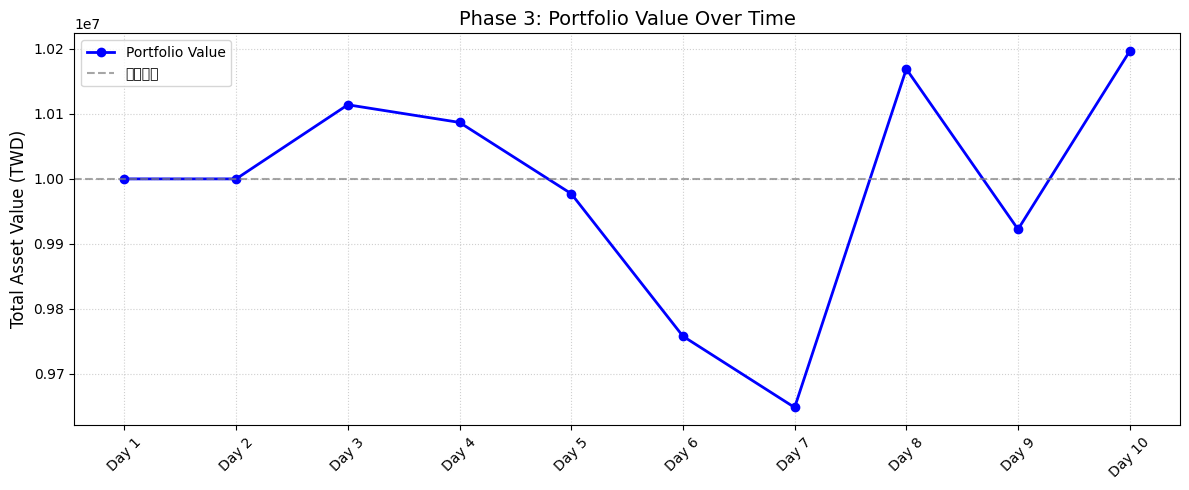

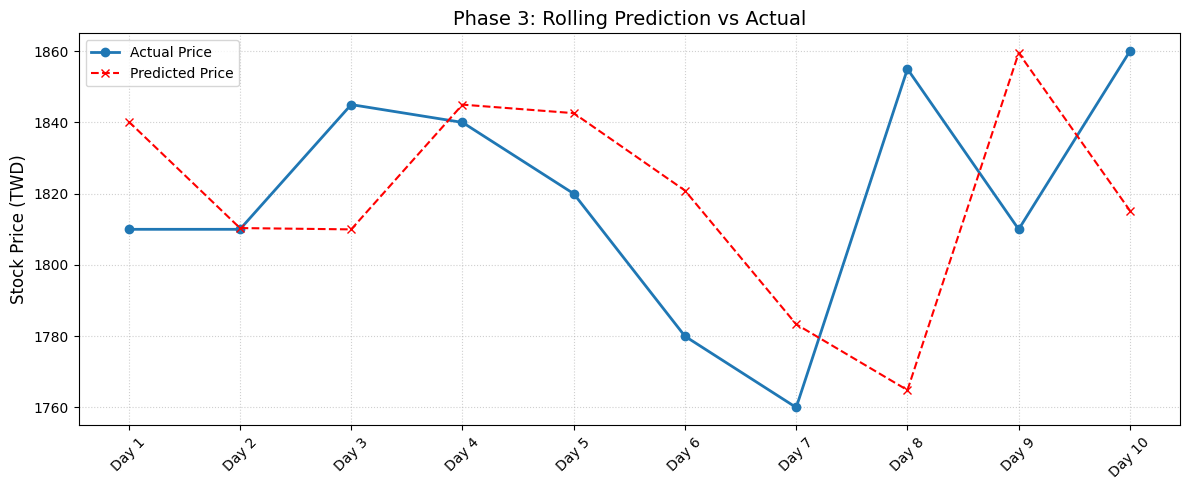


【模型預測表現 (Day 1 ~ Day 10)】
 - RMSE: 41.7964
 - MAPE: 1.87%


In [54]:
with open(TRADE_LOG_FILE, 'r') as f:
    ts = json.load(f)

if len(ts['trades']) == 0:
    print("尚未有任何交易紀錄。")
else:
    print("=======================================================")
    print("  📋 Phase 3 完整交易紀錄")
    print("=======================================================")

    # --- 手動格式化表格，確保對齊 ---
    header = (f"{'Day':>4} | {'日期':>8.5} | {'成交價':>5} | {'預測價':>5} | "
              f"{'動作':>3} | {'股數':>4} | "
              f"{'現金餘額':>11} | {'持股':>4} | {'總資產':>12} | "
              f"{'RMSE':>8} | {'MAPE(%)':>6}")
    sep = '-' * (len(header)+20)
    print(header)
    print(sep)
    for t in ts['trades']:
        row = (f"{t['day']:>4} | {t['date']:>10} | {t['trade_price']:>8.2f} | "
               f"{t['predicted_price']:>8.2f} | "
               f"{t['action']:>4} | {t.get('quantity',0):>6} | "
               f"{t['cash_after']:>14,.0f} | {t['shares_after']:>6} | "
               f"{t['daily_value']:>14,.0f} | "
               f"{t['train_rmse']:>8.4f} | {t['train_mape']:>6.2f}")
        print(row)

    # 績效摘要
    print("\n=======================================================")
    print("  📊 績效摘要")
    print("=======================================================")
    print(f"初始資產: {ts['initial_capital']:,.0f} TWD")
    print(f"目前現金: {ts['cash']:,.0f} TWD")
    print(f"目前持股: {ts['shares']:,} 股")

    portfolio_vals = [t['daily_value'] for t in ts['trades']]
    last_val = portfolio_vals[-1]
    roi = ((last_val - ts['initial_capital']) / ts['initial_capital']) * 100
    print(f"最新總資產: {last_val:,.0f} TWD")
    print(f"總報酬率 ROI: {roi:+.2f}%")

    # Max Drawdown
    peak = portfolio_vals[0]
    max_dd = 0
    for v in portfolio_vals:
        if v > peak:
            peak = v
        dd = (peak - v) / peak
        if dd > max_dd:
            max_dd = dd
    print(f"最大回撤 (Max Drawdown): {max_dd*100:.2f}%")

    total_trades = sum(1 for t in ts['trades'] if t['action'] != 'hold')
    print(f"總交易次數 (非 hold): {total_trades}")

    # 畫圖
    if len(portfolio_vals) > 1:
        fig, ax = plt.subplots(figsize=(12, 5))
        days = [f"Day {t['day']}" for t in ts['trades']]
        ax.plot(days, portfolio_vals, marker='o', linewidth=2, color='blue', label='Portfolio Value')
        ax.axhline(y=ts['initial_capital'], color='gray', linestyle='--', alpha=0.7, label='初始資金')
        ax.set_title('Phase 3: Portfolio Value Over Time', fontsize=14)
        ax.set_ylabel('Total Asset Value (TWD)', fontsize=12)
        ax.legend()
        ax.grid(True, linestyle=':', alpha=0.6)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # 畫預測 vs 成交價的比較 (Day 1 ~ Day N)
    # 每天的 predicted_price 是「前一天預測今天的股價」，對比今天的 trade_price
    if len(ts['trades']) >= 1:
        pred_prices = [t['predicted_price'] for t in ts['trades']]
        actual_prices = [t['trade_price'] for t in ts['trades']]
        day_labels = [f"Day {t['day']}" for t in ts['trades']]

        fig2, ax2 = plt.subplots(figsize=(12, 5))
        ax2.plot(day_labels, actual_prices, marker='o', label='Actual Price', linewidth=2)
        ax2.plot(day_labels, pred_prices, marker='x', label='Predicted Price', linestyle='--', color='red')
        ax2.set_title('Phase 3: Rolling Prediction vs Actual', fontsize=14)
        ax2.set_ylabel('Stock Price (TWD)', fontsize=12)
        ax2.legend()
        ax2.grid(True, linestyle=':', alpha=0.6)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # 計算預測的 RMSE / MAPE
        pred_arr = np.array(pred_prices)
        actual_arr = np.array(actual_prices)
        pred_rmse = np.sqrt(mean_squared_error(actual_arr, pred_arr))
        pred_mape = np.mean(np.abs((actual_arr - pred_arr) / actual_arr)) * 100
        print(f"\n【模型預測表現 (Day 1 ~ Day {len(ts['trades'])})】")
        print(f" - RMSE: {pred_rmse:.4f}")
        print(f" - MAPE: {pred_mape:.2f}%")